## 3 Layer network theory with non-zero threshold
### Created Sept 25

This script the min-perturbation theory for three-layer networks. The threshold is assumed to be a fixed constant shared by all neurons.

The `get_effective_weights` functions are the same as those used in zero-threshold networks. But they still work via a simple argument.

$$r = a^T (W_2 (W_1 x + b_1) + b_2)=a^T W_2 W_1 x + a^T (W_2 b_1 + b_2)$$

where $b_1, b_2$ are vector-valued thresholds. The thresholds do not affect Fisher information besides changing the effective weights.

In [2]:
%cd ~/Dropbox/codes/Perceptual_Learning/
%load_ext autoreload
%autoreload 2

import matplotlib.pyplot as plt
import numpy as np
import train_utils, torch, pickle, utils, model, copy, warnings, time
from tqdm import trange, tqdm
import response_utils as r_utils
import theory_utils as t_utils


threshold=0.01

parser = train_utils.Args('1D Gabor')
parser.add('nonlinearity', 'relu')
parser.add('loss', 'MSE') # MSE or BCE

# model parameters
parser.add('N', 100); parser.add('Nhid', 100); parser.add('n_layers', 3)

# task parameters
parser.add('sig_w', 1.2)
parser.add('sig_s', 0.2) # default value 0.2
parser.add('theta', np.pi)

# training parameter
parser.add('n_train_trials', 500)
parser.add('n_test_trials', 10000) 
parser.add('noise_var', .01)

args = parser.parse_args()

# The sig_w values to test
sig_w_array = np.linspace(0.1, 1.0, 30)

sig_w_array = np.array([sig_w_array[23]])

standard_stim = train_utils.GaborStimuli(args, simple_mode=True)
standard_net = model.Model(args)

#%% USING a in-script solver (defined below)
average_if_not_converged = True

def predict_delw_threelayer(network:model.Model, stimuli, init_guess, update_coef, max_iter):
    """
    Solve the order parameter self-consistent equations for three-layer networks.
    """
    def norm_sq(x):
        return np.linalg.norm(x)**2

    x1 = stimuli.x1_normed.numpy().reshape(-1, 1)

    # create the effective weights
    w_effs, active_inds = r_utils.get_effective_weights(network, stimuli.x0, threshold=threshold); W1, W2, W3 = w_effs
    forward_mat = W3 @ W2 @ W1

    a = train_utils.mse_optimal_a(forward_mat, stimuli)
    
    a_norm_sq = np.linalg.norm(a)**2

    # Solve self-consistent equations by iterati\on
    def iteration_eqs(p):
        u1, u2, v1, v2 = p
        one_minus_v1_u2 = 1 - v1 * u2

        one_minus_a_norm_sq_v2 = 1 - a_norm_sq * v2

        Q1 = u1 * np.eye(W1.shape[1]) + one_minus_v1_u2**-1 * u2 * W1.T @ W1
        Q2 = one_minus_a_norm_sq_v2*np.eye(W2.shape[0])-a_norm_sq*one_minus_v1_u2**-1*v1*W2 @ W2.T

        invQ2 = np.linalg.inv(Q2)

        inv_mat = Q1 + a_norm_sq*one_minus_v1_u2**-2 * W1.T @ W2.T @ invQ2 @ W2 @ W1
        _u, _s, _v = np.linalg.svd(inv_mat)
        # Lambda = np.linalg.inv(Q1 + a_norm_sq*one_minus_v1_u2**-2 * W1.T @ W2.T @ invQ2 @ W2 @ W1) @ (x1 - one_minus_v1_u2**-1 * W1.T @ W2.T @ invQ2 @ W3.T @ a)

        Lambda = np.linalg.pinv(inv_mat, rcond=_s[3] / _s[0] - 0.01) @ (x1 - one_minus_v1_u2**-1 * W1.T @ W2.T @ invQ2 @ W3.T @ a)

        U2 = invQ2 @ (W3.T @ a + a_norm_sq * one_minus_v1_u2**-1 * W2 @ W1 @ Lambda)
        
        u1_out = norm_sq(one_minus_v1_u2**-1 * (W2.T @ U2 + u2 * W1 @ Lambda))
        u2_out = norm_sq(U2)
        v1_out = norm_sq(Lambda)
        v2_out = norm_sq(one_minus_v1_u2**-1 * (W1 @ Lambda + v1 * W2.T @ U2))
        return np.array([u1_out, u2_out, v1_out, v2_out])

    # Declare op_vals a global variable, so that if the Python kernel is interrupted before predict_deltaw is complete, one can still access the trajectories of order parameters.
    global op_vals
    op_vals = [np.array(init_guess)]  # initial guesses for the order parameters

    for i in range(max_iter):
        new_vals = iteration_eqs(op_vals[-1])

        convergence_counter = 0
        for old_op, new_op in zip(op_vals[-1], new_vals):
            if np.abs(new_op - old_op) / np.abs(old_op) < 1e-2:
                convergence_counter += 1

        if i == 0:
            op_vals.append(update_coef * op_vals[-1] + (1-update_coef) * new_vals)
        else:
            op_vals.append(update_coef * op_vals[-1] + (1-update_coef) * new_vals)

        if convergence_counter == 4:
            print('===Converged===')
            break
        
        # Heuristic divergence fuse: if value exceeds some range, raise RuntimeError
        if op_vals[-1][0] > 100:
            raise RuntimeError('Divergence detected because u1>100.')
        if op_vals[-1][1] > 5000:
            raise RuntimeError('Divergence detected because u2>1000.')

        # dampen oscillations
        if (i + 1) % 1000 == 0:
            op_vals.append(np.mean(np.array(op_vals)[-1000:], axis=0))
            print(np.mean(np.array(op_vals)[-10:], axis=0))
    
    # if all iterations have been used, return an average
    if average_if_not_converged:
        if i == max_iter - 1:
            op_vals.append(np.mean(np.array(op_vals)[-10000:], axis=0))

    delW1, delW2, delW3 = t_utils.get_del_Ws_threelayer(*op_vals[-1], W1, W2, W3, a, a_norm_sq, x1)


    return np.array(op_vals), delW1, delW2, delW3, active_inds, a



/Users/haozheshan/Dropbox/codes/Perceptual_Learning
calc_MLD(): MLD error is 0.1586674362489322


## First, check if the threshold chosen is valid. A necessary condition is that for the $\theta_{tr}$, there should non-zero number of neurons active in the last layer for all parameters considered.

If this condition is violated, an `AssertionError` is thrown.

[[39, 43, 43]]
[[39, 37, 11]]


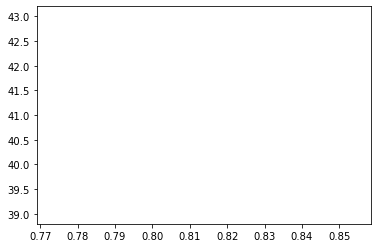

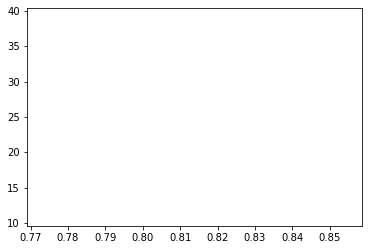

In [3]:
try_threshold = 0
n_active_bl = []
for sig_w in sig_w_array:
    args.sig_w = sig_w
    net = model.Model(args)
    active_inds = r_utils.get_active_inds(net, standard_stim.x0, threshold=try_threshold)
    n_active_bl.append([len(active_inds[1]), len(active_inds[2]), len(active_inds[3])])

plt.figure()
for i in range(3):
    plt.plot(sig_w_array, np.array(n_active_bl)[:, i])
    
try_threshold = 0.015
n_active = []
for sig_w in sig_w_array:
    args.sig_w = sig_w
    net = model.Model(args)
    active_inds = r_utils.get_active_inds(net, standard_stim.x0, threshold=try_threshold)
    n_active.append([len(active_inds[1]), len(active_inds[2]), len(active_inds[3])])

plt.figure()
for i in range(3):
    plt.plot(sig_w_array, np.array(n_active)[:, i])

print(n_active_bl)
print(n_active)

In [4]:

init_init_guess = [10, 100, .0005, 0.00001]
update_coef = 0.99
max_iter = 2000

OPs_list = [] # store the trajectories of OPs to check for convergence
OPs = np.zeros((len(sig_w_array), 4))
delw1_list = []; delw2_list = []; delw3_list = []
active_inds_list = []
a_list = []
check_list = []

tic = time.time()

for i in range(len(sig_w_array)):

    print(f'{i+1}/{len(sig_w_array)}')
    args.sig_w = sig_w_array[i]
    net = model.Model(args)
    stimuli = train_utils.GaborStimuli(args, simple_mode=True, verbose=False)

    W_effs = r_utils.get_effective_weights(net, stimuli.x0, threshold=threshold)[0]

    # Use solutions for parameters in the last iteration as initial guesses
    if i == 0:
        init_guess = init_init_guess
    elif i > 1:
            init_guess = OPs[i-1, :]

    _OPs, delw1, delw2, delw3, w_bounds, a = predict_delw_threelayer(net, stimuli, init_guess=init_guess, update_coef=update_coef, max_iter=max_iter)

    OPs[i, :] = _OPs[-1]
    OPs_list.append(_OPs)
    
    print([f'{num:.6f}' for num in _OPs[-1]])

    v_eff = (W_effs[0] + delw1).T @ (W_effs[1] + delw2).T @ (W_effs[2] + delw3).T @ a
    check_list.append(np.linalg.norm(v_eff - stimuli.x1_normed.numpy().T))

    print(f'x1 difference:{check_list[-1]:.3f}, time per run {int((time.time() - tic) / (i+1))}s')


    delw1_list.append(delw1); delw2_list.append(delw2); delw3_list.append(delw3)
    active_inds_list.append(w_bounds)
    a_list.append(a)



1/1
[2.95310746e-01 4.72487702e+00 2.84128506e+03 1.50751760e-04]
[2.84367516e-02 4.94899903e-01 1.80287327e+07 1.86668203e-04]
['1.576171', '24.840889', '541279.594099', '0.000126']
x1 difference:0.988, time per run 5s


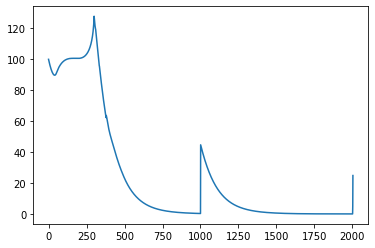

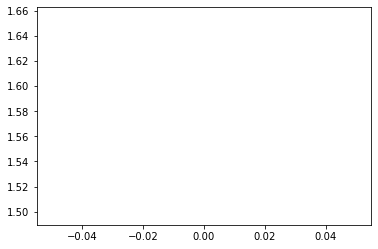

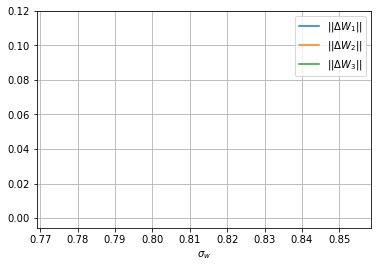

In [5]:


#%% Plot some OP solver trajectories
ind = -1
plt.figure()
plt.plot(np.array(OPs_list[ind])[:, 1])

plt.figure()
plt.plot(np.array(OPs)[:, 0])

#%%
to_ind = 40

delw1_norms = [np.linalg.norm(mat) for mat in delw1_list]
delw2_norms = [np.linalg.norm(mat) for mat in delw2_list]
delw3_norms = [np.linalg.norm(mat) for mat in delw3_list]

plt.figure()
plt.plot(sig_w_array[:to_ind], delw1_norms, label='$||\Delta W_1||$')

plt.plot(sig_w_array[:to_ind], delw2_norms, label='$||\Delta W_2||$')
plt.plot(sig_w_array[:to_ind], delw3_norms, label='$||\Delta W_3||$')
# plt.ylim(-0.01, 0.5)
plt.xlabel('$\sigma_w$'); plt.legend(); plt.grid()



## Second step. Use outputs from the iterative solver as initial gueses for fsolve.

In [173]:

from scipy.optimize import fsolve
parser = train_utils.Args('1D Gabor')
parser.add('nonlinearity', 'relu')
parser.add('loss', 'MSE') # MSE or BCE

# model parameters
args.N = 500
args.Nhid = 500

def norm_sq(x):
    return np.linalg.norm(x)**2

fsolve_OPs = np.zeros((len(sig_w_array), 4))
fsolve_delw1_list = []; fsolve_delw2_list = []; fsolve_delw3_list = []
active_inds_list = []
a_list = []
check_list = []
fsolve_errors = []

tic = time.time()

for i in trange(len(sig_w_array)):

    args.sig_w = sig_w_array[i]
    net = model.Model(args)
    stimuli = train_utils.GaborStimuli(args, simple_mode=True, verbose=False)
    

    W_effs, active_inds = r_utils.get_effective_weights(net, stimuli.x0, threshold=threshold)
    W1, W2, W3 = W_effs
    x1 = stimuli.x1_normed.numpy().T
    F = W_effs[2] @ W_effs[1] @ W_effs[0]
    a = train_utils.mse_optimal_a(F, stimuli)
    a_list.append(a)
    a_norm_sq = np.linalg.norm(a)**2
    
    def self_consistent_eqs(p):
        u1, u2, v1, v2 = p
        one_minus_v1_u2 = 1 - v1 * u2
        one_minus_a_norm_sq_v2 = 1 - a_norm_sq * v2

        Q1 = u1 * np.eye(W1.shape[1]) + one_minus_v1_u2**-1 * u2 * W1.T @ W1
        Q2 = one_minus_a_norm_sq_v2*np.eye(W2.shape[0])-a_norm_sq*one_minus_v1_u2**-1*v1*W2 @ W2.T

        invQ2 = np.linalg.inv(Q2)

        inv_mat = Q1 + a_norm_sq*one_minus_v1_u2**-2 * W1.T @ W2.T @ invQ2 @ W2 @ W1
        _u, _s, _v = np.linalg.svd(inv_mat)
        # Lambda = np.linalg.inv(Q1 + a_norm_sq*one_minus_v1_u2**-2 * W1.T @ W2.T @ invQ2 @ W2 @ W1) @ (x1 - one_minus_v1_u2**-1 * W1.T @ W2.T @ invQ2 @ W3.T @ a)

        Lambda = np.linalg.inv(inv_mat) @ (x1 - one_minus_v1_u2**-1 * W1.T @ W2.T @ invQ2 @ W3.T @ a)

        U2 = invQ2 @ (W3.T @ a + a_norm_sq * one_minus_v1_u2**-1 * W2 @ W1 @ Lambda)
        
        u1_out = norm_sq(one_minus_v1_u2**-1 * (W2.T @ U2 + u2 * W1 @ Lambda))
        u2_out = norm_sq(U2)
        v1_out = norm_sq(Lambda)
        v2_out = norm_sq(one_minus_v1_u2**-1 * (W1 @ Lambda + v1 * W2.T @ U2))
        return (u1_out - u1) / u1_out, (u2_out - u2) / u2_out, (v1_out - v1) / v1_out, (v2_out - v2) / v2_out

    fsolve_OP = fsolve(self_consistent_eqs, OPs[i], factor=0.5, maxfev=100000, xtol=1e-10)

    fsolve_OPs[i] = fsolve_OP

    # compute delW norms with fsolve parameters
    
    delW1, delW2, delW3 = t_utils.get_del_Ws_threelayer(*fsolve_OP, W1, W2, W3, a, a_norm_sq, x1)
    fsolve_delw1_list.append(delW1); fsolve_delw2_list.append(delW2); fsolve_delw3_list.append(delW3)
    
    fsolve_errors.append(self_consistent_eqs(fsolve_OP))


    # delw1_list.append(delw1); delw2_list.append(delw2); delw3_list.append(delw3)
    active_inds_list.append(active_inds)
    # a_list.append(a)

#%% Check results



  0%|          | 0/1 [00:00<?, ?it/s]

/opt/anaconda3/lib/python3.7/site-packages/scipy/optimize/minpack.py:175: RuntimeWarning: The iteration is not making good progress, as measured by the 
  improvement from the last ten iterations.
  warnings.warn(msg, RuntimeWarning)
100%|██████████| 1/1 [00:03<00:00,  3.09s/it]


## Measure Transfer
If an `IndexError` is thrown, it could be that for certain $\theta_{test}$, there are no active neurons in the last layer to read from.

In [161]:
args3

Namespace(BATCH_NAME='BATCH_NAME', N=1000, Nhid=1000, TRIAL_IND=0, cluster=0, f=None, loss='MSE', n_layers=3, n_test_trials=10000, n_train_trials=500, noise_var=0.01, nonlinearity='relu', sig_s=0.4, sig_w=0.8137931034482758, theta=6.283185307179586)

In [6]:
# create a network and load zero-threshold results into it
args3 = copy.copy(args)
args3.N = 1000
args3.Nhid = 1000
args3.theta = np.pi
bl_zero_net = model.Model(args3)
zero_net = model.Model(args3)
stimuli_large = train_utils.GaborStimuli(args3, simple_mode=True, verbose=False)
t_utils.load_theory_from_file(zero_net, 'theory_3L_sigs0P2', ind=23)

args.N = 500
args.Nhid = 500

tic = time.time()
probe_angles = np.linspace(np.pi, 2*np.pi, 64)
fi_mat = np.zeros((len(sig_w_array), len(probe_angles)))
bl_fi_mat = np.zeros((len(sig_w_array), len(probe_angles)))

zero_fi_mat = np.zeros_like(probe_angles); zero_bl_fi_mat = np.zeros_like(probe_angles)

for i in trange(len(sig_w_array)):

    args.sig_w = sig_w_array[i]
    net = model.Model(args)
    bl_fi_mat[i, :] = r_utils.get_mean_field_fi(net, stimuli, threshold=threshold)
    zero_bl_fi_mat[:] = r_utils.get_mean_field_fi(bl_zero_net, stimuli_large)
    t_utils.load_theory_changes(net, [fsolve_delw1_list[i], fsolve_delw2_list[i], fsolve_delw3_list[i]], active_inds_list[i])

    for j in range(len(probe_angles)):
        args.theta = probe_angles[j]
        stimuli = train_utils.GaborStimuli(args, simple_mode=True, verbose=False)
        fi_mat[i, j] = r_utils.get_mean_field_fi(net, stimuli, threshold=threshold, to_layer=3)
        
        args3.theta = probe_angles[j]
        stimuli_large = train_utils.GaborStimuli(args3, simple_mode=True, verbose=False)
        zero_fi_mat[j] = r_utils.get_mean_field_fi(zero_net, stimuli_large)

TypeError: string indices must be integers

## Compare normalized transfer between zero-threshold networks and non-zero-threshold networks

The code below does not compute transfer for zero-threshold networks. It just loads a pickle object that has a np array. So you have to check whether this is the right data to pull.

In [7]:
normalized_transfer = (fi_mat - bl_fi_mat) / (fi_mat - bl_fi_mat).max(axis=1, keepdims=True)
normalized_transfer_zero = (zero_fi_mat - zero_bl_fi_mat) / (zero_fi_mat - zero_bl_fi_mat).max(keepdims=True)

plt.figure()

plt.plot(probe_angles, normalized_transfer_zero)
plt.plot(probe_angles, normalized_transfer[0])
plt.axhline(0); plt.xlabel('theta'); plt.ylabel('Normalized transfer')

plt.savefig('figures/raw/transfer_with_threshold_sigs0P2.svg')

bl_net = model.Model(args)
r_mat = r_utils.get_response_mats(bl_net, 3, args.sig_s, 500, threshold)
r_mat_threshold0 = r_utils.get_response_mats(bl_net, 3, args.sig_s, 500, 0)

plt.figure()
plt.plot(r_mat[250, :])
plt.plot(r_mat_threshold0[250, :])
plt.savefig('figures/raw/tuning_with_threshold_sigs0P2.svg')

NameError: name 'fi_mat' is not defined

In [1]:
normalized_transfer = (fi_mat - bl_fi_mat) / (fi_mat - bl_fi_mat).max(axis=1, keepdims=True)
normalized_transfer_zero = (zero_fi_mat - zero_bl_fi_mat) / (zero_fi_mat - zero_bl_fi_mat).max(keepdims=True)

plt.figure()

plt.plot(probe_angles, normalized_transfer_zero)
plt.plot(probe_angles, normalized_transfer[0])
plt.axhline(0); plt.xlabel('theta'); plt.ylabel('Normalized transfer')

# plt.savefig('figures/raw/transfer_with_threshold_sigs0P2.svg')

bl_net = model.Model(args)
r_mat = r_utils.get_response_mats(bl_net, 3, args.sig_s, 500, threshold)
r_mat_threshold0 = r_utils.get_response_mats(bl_net, 3, args.sig_s, 500, 0)

plt.figure()
plt.plot(r_mat[250, :])
plt.plot(r_mat_threshold0[250, :])
# plt.savefig('figures/raw/tuning_with_threshold_sigs0P2.svg')

NameError: name 'fi_mat' is not defined

##### 